In [20]:

#!/usr/bin/env python3
"""
Designing a convolutional linear data preconditioner for MNIST diffusion (LaTeX -> code)

Implements the LP feasibility problem + bisection over gamma in Eq. (final_LP_bisect_edit),
optimizing over Fourier-domain weights s (for M^T M) and s_max, then constructs

    M = F^* diag(sqrt(s)) F

as a 784x784 *explicit* dense matrix (numpy array), with M acting on vec(X) where vec is
row-major flatten of a 28x28 image.

Hard requirements satisfied:
  - Uses torchvision MNIST
  - cvxpy for LP
  - bisection/monotone search over gamma
  - constructs explicit 784x784 M
  - minimal example at bottom

Notes:
  - The LaTeX discusses estimating class means from MNIST and a shared covariance Sigma0 = sigma0^2 I.
    Per user instruction, this script defaults to *placeholder means* (random 28x28 per class)
    and a placeholder sigma0 (default 1.0). You can switch to empirical means easily.
  - The diffusion schedule used to compute g(t) matches the provided DDPM code snippet via:
        alpha(t)^2  <->  alpha_bar[t]
        sigma_t^2   <->  1 - alpha_bar[t]
        g(t)        =    alpha_bar[t] / (1 - alpha_bar[t])
"""



'\nDesigning a convolutional linear data preconditioner for MNIST diffusion (LaTeX -> code)\n\nImplements the LP feasibility problem + bisection over gamma in Eq. (final_LP_bisect_edit),\noptimizing over Fourier-domain weights s (for M^T M) and s_max, then constructs\n\n    M = F^* diag(sqrt(s)) F\n\nas a 784x784 *explicit* dense matrix (numpy array), with M acting on vec(X) where vec is\nrow-major flatten of a 28x28 image.\n\nHard requirements satisfied:\n  - Uses torchvision MNIST\n  - cvxpy for LP\n  - bisection/monotone search over gamma\n  - constructs explicit 784x784 M\n  - minimal example at bottom\n\nNotes:\n  - The LaTeX discusses estimating class means from MNIST and a shared covariance Sigma0 = sigma0^2 I.\n    Per user instruction, this script defaults to *placeholder means* (random 28x28 per class)\n    and a placeholder sigma0 (default 1.0). You can switch to empirical means easily.\n  - The diffusion schedule used to compute g(t) matches the provided DDPM code snippet v

In [21]:
import math
import numpy as np
import torch
import torchvision
import torchvision.transforms as T
import cvxpy as cp

In [22]:
# -----------------------------
# Dimensions
# -----------------------------
H = 28 
W = 28 
D = H * W  



In [23]:
# -----------------------------
# Vectorization (any fixed vec; we choose row-major)
# -----------------------------
def vec_img(x_hw: np.ndarray) -> np.ndarray:
    """vec: R^{H x W} -> R^D, row-major."""
    assert x_hw.shape == (H, W)
    return x_hw.reshape(-1)  # row-major


def unvec_img(x_d: np.ndarray) -> np.ndarray:
    """inverse vec: R^D -> R^{H x W}, row-major."""
    assert x_d.shape == (D,)
    return x_d.reshape(H, W)



In [24]:
# -----------------------------
# Diffusion schedule -> g(t)
# -----------------------------
def ddpm_g_from_linear_beta_schedule(
    T_steps: int = 400,               
    beta_start: float = 1e-4,         
    beta_end: float = 0.02,           
    clamp_eps: float = 1e-12,         
) -> np.ndarray:
    """
    Computes g(t) = alpha(t)^2 / sigma_t^2 using the discrete DDPM marginal:
        x_t = sqrt(alpha_bar[t]) x0 + sqrt(1 - alpha_bar[t]) eps
    so:
        alpha(t)^2  = alpha_bar[t]
        sigma_t^2   = 1 - alpha_bar[t]
        g(t)        = alpha_bar[t] / (1 - alpha_bar[t])
    """
    betas = torch.linspace(beta_start, beta_end, T_steps, device="cpu")  
    alphas = 1.0 - betas
    alpha_bar = torch.cumprod(alphas, dim=0)  
    denom = torch.clamp(1.0 - alpha_bar, min=clamp_eps)
    g = (alpha_bar / denom).detach().cpu().numpy().astype(np.float64)    
    return g

In [25]:
# -----------------------------
# MNIST
# -----------------------------
def load_mnist_train():
    tfm = T.Compose([T.ToTensor()])  # gives [1,28,28] in [0,1]
    ds = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=tfm)
    return ds


# -----------------------------
# Means (mu_i) and sigma0 
# -----------------------------
def get_class_means(
    mnist_train,
    use_placeholder_means: bool = False,  
    placeholder_seed: int = 0,            
    max_per_class: int = 5000,      
) -> np.ndarray:
    """
    Returns mu[i] as 28x28 arrays, shape [10, H, W].

    If use_placeholder_means=True:
        mu_i are random in [0,1] (placeholder, as requested).
    Else:
        empirical mean per class from MNIST train set (as in LaTeX implementation section).
    """
    if use_placeholder_means:
        rng = np.random.default_rng(placeholder_seed)
        mu = rng.random(size=(10, H, W), dtype=np.float64)  # in [0,1]
        return mu

    sums = np.zeros((10, H, W), dtype=np.float64)
    counts = np.zeros((10,), dtype=np.int64)

    for x, y in mnist_train:
        yi = int(y)
        if counts[yi] >= max_per_class:
            if np.all(counts >= max_per_class):
                break
            continue
        x_hw = x[0].numpy().astype(np.float64)
        sums[yi] += x_hw
        counts[yi] += 1

    for i in range(10):
        if counts[i] == 0:
            raise RuntimeError(f"No samples collected for class {i}. Increase max_per_class.")
    mu = sums / counts[:, None, None]
    return mu

In [26]:
# -----------------------------
# D_close / D_far construction
# -----------------------------
def pairs_within(classes):
    cs = sorted(list(classes))
    out = []
    for a in range(len(cs)):
        for b in range(a + 1, len(cs)):
            out.append((cs[a], cs[b]))
    return out


def pairs_across(intra_classes, inter_classes):
    out = []
    for i in sorted(list(intra_classes)):
        for j in sorted(list(inter_classes)):
            if i == j:
                raise ValueError("intra_classes and inter_classes must be disjoint.")
            out.append((i, j))
    return out


def abs_dhat_sq_from_means(mu_hw: np.ndarray, pair_list):
    """
    For each (i,j) in pair_list, compute d = mu_i - mu_j (28x28),
    then d_hat = FFT2(d, norm='ortho'), and return |d_hat|^2 flattened (row-major).
    Returns A of shape [num_pairs, D], dtype float64.
    """
    A = []
    for (i, j) in pair_list:
        d_hw = (mu_hw[i] - mu_hw[j]).astype(np.float64)
        d_hat = np.fft.fft2(d_hw, norm="ortho")  # complex [H,W]
        A.append((np.abs(d_hat) ** 2).reshape(-1))  # flatten row-major
    if len(A) == 0:
        return np.zeros((0, D), dtype=np.float64)
    return np.stack(A, axis=0).astype(np.float64)


# -----------------------------
# Symmetry constraints
# -----------------------------
def symmetry_index_pairs(H_, W_):
    """
    Returns list of (idx, mirror_idx) with idx < mirror_idx, where:
        mirror(k,l) = ((H-k)%H, (W-l)%W)
    in row-major flattening idx = k*W + l.
    """
    pairs = []
    for k in range(H_):
        for l in range(W_):
            kk = (-k) % H_
            ll = (-l) % W_
            idx = k * W_ + l
            midx = kk * W_ + ll
            if idx < midx:
                pairs.append((idx, midx))
    return pairs



In [27]:
# -----------------------------
# LP builder
# -----------------------------
def build_lp_problem(
    A_close: np.ndarray,
    A_far: np.ndarray,
    g_grid: np.ndarray,
    delta_close: float,      
    sigma0: float,           
    eps_s: float,            
):
    
    assert A_close.shape[1] == D and A_far.shape[1] == D
    s = cp.Variable(D)          
    s_max = cp.Variable()       
    gamma_sq = cp.Parameter(nonneg=True)  

    constraints = []

    constraints += [s_max >= 0]
    constraints += [s >= eps_s]
    constraints += [s <= s_max]

    for idx, midx in symmetry_index_pairs(H, W):
        constraints += [s[idx] == s[midx]]
    
    if A_close.shape[0] > 0:
        for g in g_grid:
            constraints += [g * (A_close @ s) <= (delta_close ** 2) * np.ones(A_close.shape[0])]

   
    if A_far.shape[0] > 0:
        for g in g_grid:
            rhs = gamma_sq * (1.0 + (sigma0 ** 2) * g * s_max)  # scalar affine in s_max
            constraints += [g * (A_far @ s) >= rhs * np.ones(A_far.shape[0])]

    objective = cp.Minimize(s_max)

    problem = cp.Problem(objective, constraints)
    return problem, s, s_max, gamma_sq


# -----------------------------
# Bisection on gamma
# -----------------------------
def bisect_max_gamma(
    problem,
    s_var,
    smax_var,
    gamma_sq_param,
    gamma_hi_init: float = 1.0,
    gamma_hi_max: float = 1e3,
    bisection_iters: int = 25,
    solver: str = "ECOS",
    verbose_solver: bool = False,   # <-- set False to suppress solver spam
    print_progress: bool = True,    # <-- compact one-line logs
):
    """
    Monotone search (bracketing + bisection) for max feasible gamma.
    Returns: (gamma_star, s_star, smax_star, history)

    history is a dict with arrays you can plot:
      - attempted_gamma[k]
      - feasible[k] (bool)
      - best_feasible_gamma[k]
      - phase[k] in {"bracket","bisect"}
    """

    history = {
        "phase": [],
        "attempted_gamma": [],
        "feasible": [],
        "best_feasible_gamma": [],
        "status": [],
    }

    def log(phase, gamma, ok, best, status):
        history["phase"].append(phase)
        history["attempted_gamma"].append(float(gamma))
        history["feasible"].append(bool(ok))
        history["best_feasible_gamma"].append(float(best))
        history["status"].append(str(status))

    def solve_for_gamma(gamma):
        gamma_sq_param.value = float(gamma * gamma)
        try:
            problem.solve(solver=solver, verbose=verbose_solver)
        except Exception as e:
            # Treat solver error as infeasible, but record status clearly
            return False, None, None, f"error: {type(e).__name__}"

        status = problem.status
        ok = status in (cp.OPTIMAL, cp.OPTIMAL_INACCURATE)
        if ok:
            s_val = np.array(s_var.value).reshape(-1).astype(np.float64)
            smax_val = float(smax_var.value)
            return True, s_val, smax_val, status
        return False, None, None, status

    # --- Check gamma=0 feasibility (should be feasible; otherwise constraints too tight)
    ok0, s0, smax0, st0 = solve_for_gamma(0.0)
    log("bracket", 0.0, ok0, 0.0 if ok0 else 0.0, st0)
    if print_progress:
        print(f"[bracket] gamma=0.0 -> {'FEASIBLE' if ok0 else 'INFEASIBLE'} (status={st0})")

    if not ok0:
        raise RuntimeError(
            "LP infeasible even at gamma=0. "
            "This usually means your close constraints + eps_s are too strict."
        )

    gamma_lo = 0.0
    s_best, smax_best = s0, smax0

    # --- Bracket upper bound by doubling until infeasible
    gamma_hi = float(gamma_hi_init)
    while gamma_hi <= gamma_hi_max:
        ok, s_val, smax_val, st = solve_for_gamma(gamma_hi)
        if ok:
            gamma_lo = gamma_hi
            s_best, smax_best = s_val, smax_val
            log("bracket", gamma_hi, True, gamma_lo, st)
            if print_progress:
                print(f"[bracket] gamma={gamma_hi:.6g} -> FEASIBLE (best={gamma_lo:.6g})")
            gamma_hi *= 2.0
        else:
            log("bracket", gamma_hi, False, gamma_lo, st)
            if print_progress:
                print(f"[bracket] gamma={gamma_hi:.6g} -> INFEASIBLE (best={gamma_lo:.6g}, status={st})")
            break

    gamma_hi = min(gamma_hi, gamma_hi_max)

    # --- Bisection
    for it in range(bisection_iters):
        mid = 0.5 * (gamma_lo + gamma_hi)
        ok, s_val, smax_val, st = solve_for_gamma(mid)

        if ok:
            gamma_lo = mid
            s_best, smax_best = s_val, smax_val
            log("bisect", mid, True, gamma_lo, st)
            if print_progress:
                print(f"[bisect {it:02d}] gamma={mid:.6g} -> FEASIBLE (best={gamma_lo:.6g})")
        else:
            gamma_hi = mid
            log("bisect", mid, False, gamma_lo, st)
            if print_progress:
                print(f"[bisect {it:02d}] gamma={mid:.6g} -> INFEASIBLE (best={gamma_lo:.6g}, status={st})")

    return gamma_lo, s_best, smax_best, history



In [ ]:
# -----------------------------
# Construct M 784x784 from s*
# -----------------------------
def apply_M_fft(x_hw: np.ndarray, sqrt_s_hw: np.ndarray) -> np.ndarray:
    """
    Y = M X via Fourier-domain rule:
      X_hat = DFT2(X), Y_hat = sqrt(s) * X_hat, Y = IDFT2(Y_hat)
    """
    X_hat = np.fft.fft2(x_hw, norm="ortho")
    Y_hat = sqrt_s_hw * X_hat
    y_hw = np.fft.ifft2(Y_hat, norm="ortho")
    y_hw = np.real_if_close(y_hw, tol=1e3)  # should be real if symmetry satisfied
    return np.asarray(y_hw, dtype=np.float64)


def build_dense_M_from_s(s_hw: np.ndarray) -> np.ndarray:
    assert s_hw.shape == (H, W)
    sqrt_s_hw = np.sqrt(s_hw)

    M = np.zeros((D, D), dtype=np.float64)
    for p in range(D):
        e = np.zeros((D,), dtype=np.float64)
        e[p] = 1.0
        e_hw = unvec_img(e)
        y_hw = apply_M_fft(e_hw, sqrt_s_hw)
        M[:, p] = vec_img(y_hw)
    return M


def build_dense_Minv_from_s(s_hw: np.ndarray) -> np.ndarray:
    

    assert np.all(s_hw > 0), "Need s[ω] > 0 to build M^{-1}."
    inv_sqrt_s_hw = 1.0 / np.sqrt(s_hw)

    Minv = np.zeros((D, D), dtype=np.float64)
    for p in range(D):
        e = np.zeros((D,), dtype=np.float64)
        e[p] = 1.0
        e_hw = unvec_img(e)
        # apply inverse in Fourier domain
        E_hat = np.fft.fft2(e_hw, norm="ortho")
        X_hat = inv_sqrt_s_hw * E_hat
        x_hw = np.fft.ifft2(X_hat, norm="ortho")
        x_hw = np.real_if_close(x_hw, tol=1e3)
        Minv[:, p] = vec_img(np.asarray(x_hw, dtype=np.float64))
    return Minv



In [29]:
import matplotlib.pyplot as plt
import numpy as np

def plot_gamma_bisection_history(history, title="Bisection progress (gamma)"):
    """
    Plots:
      - attempted gamma each iteration (feasible vs infeasible markers)
      - best feasible gamma so far (step-like curve)

    Handles infeasible iterations by plotting them with red X markers.
    """
    gam = np.array(history["attempted_gamma"], dtype=float)
    feas = np.array(history["feasible"], dtype=bool)
    best = np.array(history["best_feasible_gamma"], dtype=float)
    phase = np.array(history["phase"])

    x = np.arange(len(gam))

    plt.figure(figsize=(9, 4))
    plt.title(title)

    # attempted gammas (feasible / infeasible)
    plt.scatter(x[feas], gam[feas], marker="o", label="attempted gamma (feasible)")
    plt.scatter(x[~feas], gam[~feas], marker="x", label="attempted gamma (infeasible)")

    # best feasible so far
    plt.plot(x, best, linewidth=2, label="best feasible gamma so far")

    # optionally show which points were bracket vs bisect (faint vertical separators)
    # Comment out if you want even less clutter.
    for i in np.where(phase == "bisect")[0][:1]:
        plt.axvline(i - 0.5, alpha=0.2)

    plt.xlabel("solve call index (bracket + bisect)")
    plt.ylabel("gamma")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [36]:
# -----------------------------
# design
# -----------------------------
def design_mnist_preconditioner(
    intra_classes,                      
    inter_classes,                      
    time_grid=None,                     
    delta_close: float = 0.5,           
    sigma0: float = 3.121,              
    eps_s: float = 1e-8,                
    T_steps: int = 400,                 
    beta_start: float = 1e-4,           
    beta_end: float = 0.02,             
    # Means 
    use_placeholder_means: bool = True, 
    placeholder_seed: int = 0,          
    max_per_class: int = 5000,          
    # Bisection 
    gamma_hi_init: float = 1.0,         
    gamma_hi_max: float = 200.0,        
    bisection_iters: int = 20,          
    # CVXPY
    solver: str = "ECOS",               
    verbose: bool = False,
):
    intra_classes = set(intra_classes)
    inter_classes = set(inter_classes)
    if len(intra_classes & inter_classes) > 0:
        raise ValueError("intra_classes and inter_classes must be disjoint.")
    for c in list(intra_classes | inter_classes):
        if c not in set(range(10)):
            raise ValueError("Classes must be in {0,...,9}.")

    if time_grid is None:
        time_grid = [50,51,52]

    g_all = ddpm_g_from_linear_beta_schedule(T_steps=T_steps, beta_start=beta_start, beta_end=beta_end)
    time_grid = [int(t) for t in time_grid if 0 <= int(t) < T_steps]
    if len(time_grid) == 0:
        raise ValueError("time_grid must contain at least one valid index in [0, T_steps-1].")
    g_grid = g_all[time_grid].astype(np.float64)

    mnist_train = load_mnist_train()
    mu_hw = get_class_means(
        mnist_train,
        use_placeholder_means=use_placeholder_means,
        placeholder_seed=placeholder_seed,
        max_per_class=max_per_class,
    )  

    close_pairs = pairs_within(intra_classes)  
    far_pairs = pairs_across(intra_classes, inter_classes)  

    A_close = abs_dhat_sq_from_means(mu_hw, close_pairs)  
    A_far = abs_dhat_sq_from_means(mu_hw, far_pairs)      

    problem, s_var, smax_var, gamma_sq_param = build_lp_problem(
        A_close=A_close,
        A_far=A_far,
        g_grid=g_grid,
        delta_close=delta_close,
        sigma0=sigma0,
        eps_s=eps_s,
    )
    

    gamma_star, s_star, smax_star, hist = bisect_max_gamma(
    problem=problem,
    s_var=s_var,
    smax_var=smax_var,
    gamma_sq_param=gamma_sq_param,
    gamma_hi_init=gamma_hi_init,
    gamma_hi_max=gamma_hi_max,
    bisection_iters=bisection_iters,
    solver=solver,
    verbose_solver=False,   # suppress CVXPY/SCS/ECOS iteration spam
    print_progress=True)    # one-line per attempt: FEASIBLE/INFEASIBLE + gamma

    
    s_hw = s_star.reshape(H, W)

    M = build_dense_M_from_s(s_hw)

    return {
    "gamma_star": float(gamma_star),
    "s_star": s_star,
    "s_max_star": float(smax_star),
    "M": M,
    "time_grid": time_grid,
    "g_grid": g_grid,
    "mu_hw": mu_hw,
    "bisect_history": hist}   # <-- add this




In [37]:
# -----------------------------
# Example
# -----------------------------
if __name__ == "__main__":
    intra = {6,9}
    inter = {1,7}

    out = design_mnist_preconditioner(
        intra_classes=intra,
        inter_classes=inter,
        time_grid=[50,51,52],
        delta_close=10.0,         
        sigma0=3.121,              
        eps_s=1e-2,              
        T_steps=400,
        beta_start=1e-4,
        beta_end=0.02,
        use_placeholder_means=True,
        placeholder_seed=0,
        bisection_iters=15,
        gamma_hi_init=1.0,
        gamma_hi_max=200.0,
        solver="SCS",
        verbose=True,
    )

    gamma_star = out["gamma_star"]
    s_max_star = out["s_max_star"]
    M = out["M"]

    print("=== Preconditioner design complete ===")
    print(f"gamma_star ≈ {gamma_star:.6f}")
    print(f"s_max_star ≈ {s_max_star:.6f}")
    print(f"M shape: {M.shape}, dtype: {M.dtype}")
    print(f"M Fro norm: {np.linalg.norm(M, ord='fro'):.6f}")

    mnist_train = load_mnist_train()
    x, y = mnist_train[0]  # x: [1,28,28]
    x_hw = x[0].numpy().astype(np.float64)
    x_vec = vec_img(x_hw)

    y_vec = M @ x_vec
    y_hw = unvec_img(y_vec)

    print("\n=== Example application to one MNIST image ===")
    print(f"Original label: {int(y)}")
    print(f"x_vec norm: {np.linalg.norm(x_vec):.6f}")
    print(f"y_vec norm: {np.linalg.norm(y_vec):.6f}")
    print(f"y_hw stats: min={y_hw.min():.6f}, max={y_hw.max():.6f}, mean={y_hw.mean():.6f}")

    s_hw = out["s_star"].reshape(H, W)
    Minv = build_dense_Minv_from_s(s_hw)
    x_rec = Minv @ y_vec
    rel_err = np.linalg.norm(x_rec - x_vec) / (np.linalg.norm(x_vec) + 1e-12)
    print("\n=== Inversion check (M^{-1} M x) ===")
    print(f"relative reconstruction error: {rel_err:.6e}")

    # Save M if desired
    np.save("mnist_preconditioner_M.npy", M)
    print("\nSaved: mnist_preconditioner_M.npy")

[bracket] gamma=0.0 -> FEASIBLE (status=optimal)
[bracket] gamma=1 -> FEASIBLE (best=1)
[bracket] gamma=2 -> FEASIBLE (best=2)
[bracket] gamma=4 -> INFEASIBLE (best=2, status=infeasible)
[bisect 00] gamma=3 -> FEASIBLE (best=3)
[bisect 01] gamma=3.5 -> INFEASIBLE (best=3, status=infeasible)
[bisect 02] gamma=3.25 -> FEASIBLE (best=3.25)
[bisect 03] gamma=3.375 -> INFEASIBLE (best=3.25, status=infeasible)
[bisect 04] gamma=3.3125 -> FEASIBLE (best=3.3125)


/tmp/ipykernel_2563394/602324348.py:87: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  problem.solve(solver=solver, verbose=verbose_solver)


[bisect 05] gamma=3.34375 -> FEASIBLE (best=3.34375)
[bisect 06] gamma=3.35938 -> INFEASIBLE (best=3.34375, status=infeasible)
[bisect 07] gamma=3.35156 -> INFEASIBLE (best=3.34375, status=infeasible)
[bisect 08] gamma=3.34766 -> INFEASIBLE (best=3.34375, status=infeasible)
[bisect 09] gamma=3.3457 -> INFEASIBLE (best=3.34375, status=infeasible)
[bisect 10] gamma=3.34473 -> INFEASIBLE (best=3.34375, status=infeasible)
[bisect 11] gamma=3.34424 -> FEASIBLE (best=3.34424)
[bisect 12] gamma=3.34448 -> FEASIBLE (best=3.34448)
[bisect 13] gamma=3.3446 -> INFEASIBLE (best=3.34448, status=infeasible)
[bisect 14] gamma=3.34454 -> FEASIBLE (best=3.34454)
=== Preconditioner design complete ===
gamma_star ≈ 3.344543
s_max_star ≈ 0.056352
M shape: (784, 784), dtype: float64
M Fro norm: 6.456135

=== Example application to one MNIST image ===
Original label: 5
x_vec norm: 9.557696
y_vec norm: 2.176760
y_hw stats: min=-0.028425, max=0.252121, mean=0.032691
HERE
HELLO WORLD
[]
0

=== Inversion check 

In [14]:
M_t = torch.from_numpy(M)               
M_t = M_t.to(dtype=torch.float32).cpu()    # save

torch.save(M_t, "M_784.pt")

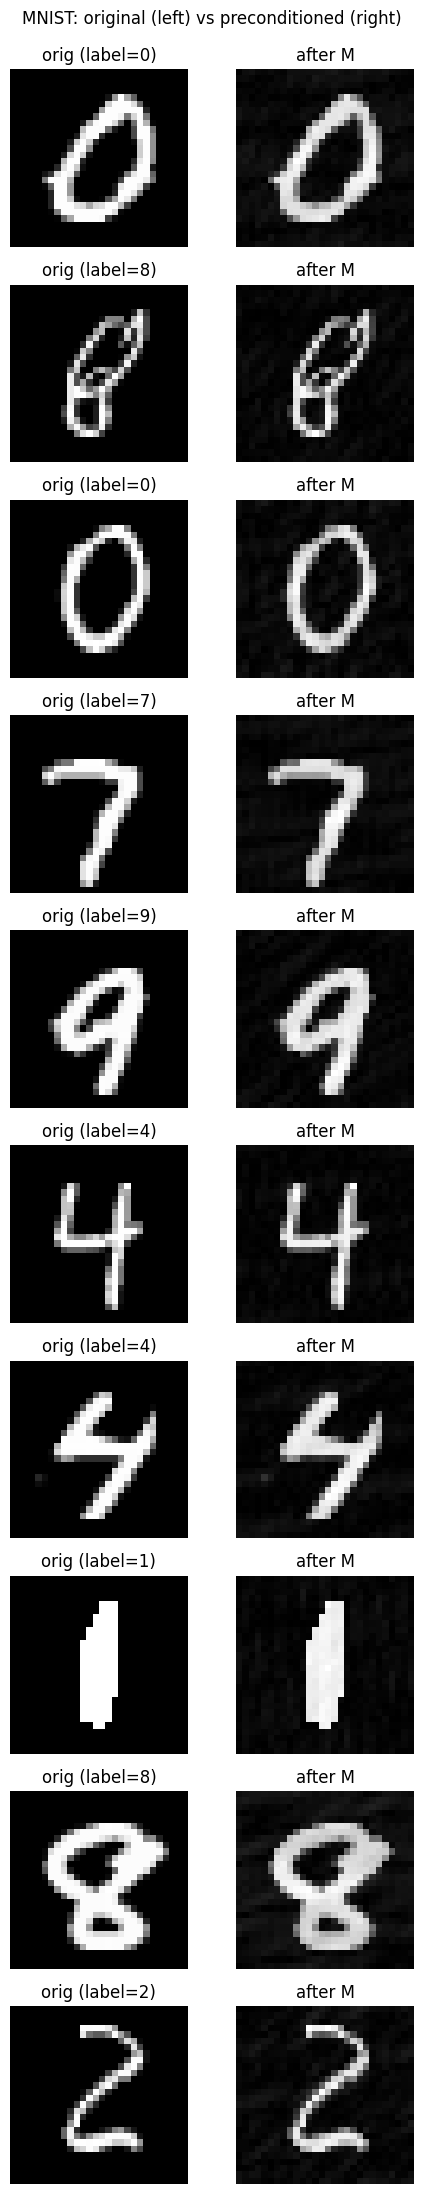

In [34]:
# -----------------------------
# Visualization: before/after applying the convolutional operator defined by s_star
# -----------------------------
import numpy as np
import matplotlib.pyplot as plt
import torchvision

def apply_preconditioner_fft(x_hw: np.ndarray, s_flat: np.ndarray) -> np.ndarray:
    """
    Apply Y = M X where M = F^* diag(sqrt(s)) F (LaTeX),
    using 2D FFTs directly (no dense 784x784 needed).
    x_hw: (28,28) float
    s_flat: (784,) nonnegative real weights indexed by frequency (row-major k,l flatten)
    """
    s_hw = s_flat.reshape(28, 28).astype(np.float64)

    s_hw = np.maximum(s_hw, 0.0)
    sqrt_s = np.sqrt(s_hw)

    X_hat = np.fft.fft2(x_hw, norm="ortho")
    Y_hat = sqrt_s * X_hat
    y_hw = np.fft.ifft2(Y_hat, norm="ortho")
    y_hw = np.real_if_close(y_hw, tol=1e3)
    return np.asarray(y_hw, dtype=np.float64)

def show_before_after_pairs(
    out_dict,
    n_pairs: int = 12,
    seed: int = 0,
    normalize_each: bool = True,
    use_absolute: bool = True,
    title: str = "MNIST: original (left) vs preconditioned (right)",
):
    """
    Displays n_pairs random MNIST train images (original vs preconditioned).
    normalize_each: if True, scales each image to [0,1] for display separately.
    use_absolute: if True, displays abs(preconditioned) (sometimes helpful).
    """
    s_star = out_dict["s_star"]  # (784,)
    ds = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=torchvision.transforms.ToTensor())

    rng = np.random.default_rng(seed)
    idxs = rng.choice(len(ds), size=n_pairs, replace=False)

    fig, axes = plt.subplots(n_pairs, 2, figsize=(5, 2.2 * n_pairs))
    if n_pairs == 1:
        axes = np.array([axes]) 

    fig.suptitle(title, y=0.995)

    for r, idx in enumerate(idxs):
        x_t, y = ds[int(idx)]
        x_hw = x_t[0].numpy().astype(np.float64)

        y_hw = apply_preconditioner_fft(x_hw, s_star)
        if use_absolute:
            y_hw = np.abs(y_hw)

        def disp(img):
            if not normalize_each:
                return img
            lo, hi = float(img.min()), float(img.max())
            if hi - lo < 1e-12:
                return np.zeros_like(img)
            return (img - lo) / (hi - lo)

        ax0, ax1 = axes[r, 0], axes[r, 1]
        ax0.imshow(disp(x_hw), cmap="gray")
        ax1.imshow(disp(y_hw), cmap="gray")

        ax0.set_title(f"orig (label={int(y)})")
        ax1.set_title("after M")

        ax0.axis("off")
        ax1.axis("off")

    plt.tight_layout()
    plt.show()

show_before_after_pairs(out, n_pairs=10, seed=0, normalize_each=True)

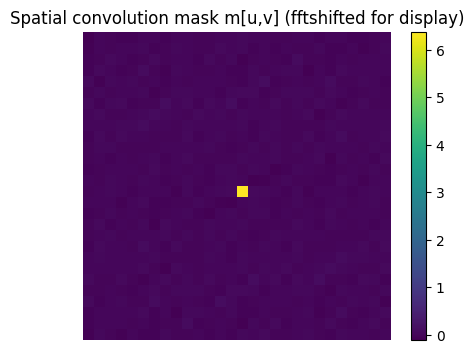

In [35]:
# ------------------------------------------------------------
# View the *spatial convolution mask/kernel* corresponding to s[ω]
# (consistent with the same row/column stacking used when building M)
#
# Recall: M = F^* diag(sqrt(s)) F
# So sqrt(s)[k,l] is the frequency response, and the spatial kernel m[u,v]
# is the inverse 2D DFT of sqrt(s).
# ------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

H = W = 28

def s_to_kernel_hw(s_flat: np.ndarray, clip_negative: bool = True) -> np.ndarray:
    """
    Convert s[ω] (flattened row-major over (k,l)) into the spatial kernel m[u,v].

    This matches the convention used in the earlier construction:
      - images are treated as (H,W) arrays
      - vec() is row-major flatten
      - frequency grid ω=(k,l) is stored row-major (k major, l minor)
      - FFT/IFFT use norm='ortho'
    """
    assert s_flat.shape == (H * W,), f"expected shape {(H*W,)}, got {s_flat.shape}"
    s_hw = s_flat.reshape(H, W).astype(np.float64)  # row-major -> (k,l) grid

    if clip_negative:
        # If your LP solver produced tiny negatives (e.g. -1e-6), clip for sqrt.
        s_hw = np.maximum(s_hw, 0.0)

    sqrt_s_hw = np.sqrt(s_hw)

    # Spatial kernel (circular convolution mask):
    # m = IDFT2( sqrt(s) )
    m_hw = np.fft.ifft2(sqrt_s_hw, norm="ortho")
    m_hw = np.real_if_close(m_hw, tol=1e3)  # should be real if symmetry constraints held
    return np.asarray(m_hw, dtype=np.float64)

def show_kernel_heatmap(s_flat: np.ndarray, center: bool = True, title: str = "Spatial convolution mask m[u,v]"):
    """
    Visualize the spatial kernel as a heatmap.
    - center=True uses fftshift so the (0,0) impulse position appears centered for readability.
      (Computation uses the unshifted kernel; shifting is only for display.)
    """
    m_hw = s_to_kernel_hw(s_flat)

    m_vis = np.fft.fftshift(m_hw) if center else m_hw

    plt.figure(figsize=(5, 4))
    plt.title(title + (" (fftshifted for display)" if center else ""))
    plt.imshow(m_vis, aspect="equal")
    plt.colorbar()
    plt.axis("off")
    plt.show()

    return m_hw  # return the *actual* (unshifted) kernel used by circular convolution

# -----------------------------
# Example drop-in usage:
# -----------------------------
# Assuming you have `out` from design_mnist_preconditioner(...)
m_hw = show_kernel_heatmap(out["s_star"], center=True)
#
# `m_hw` is the 28x28 convolution mask for circular convolution as defined in the LaTeX:
#   M_m(X)[u,v] = sum_{a,b} m[a,b] * X[(u-a) mod H, (v-b) mod W]